In [ ]:
import sys
#!{sys.executable} -m pip install lpips

import torch                                 #The main library for deep learning
import torch.nn as nn                        #Neural Network module in PyTorch
from torch.nn import AdaptiveAvgPool2d
import torch.nn.functional as F
import torch.optim as optim                  #contains optimizers for training neural networks(SGD,Adam)
from torchvision import datasets             #torchvision is PyTorch library for vision tasks tandard datasets (MNIST, CIFAR10, ImageNet...) , 
from torchvision import datasets, transforms #Preprocessing (resize, normalize, convert to tensor, etc.)
from torchvision.models import inception_v3
from torch.utils.data import DataLoader      #Loads dataset in batches and allows shuffling
from torch.utils.data import Subset          #selects a subset of the dataset, useful for debugging or small experiments.

import numpy as np
import matplotlib.pyplot as plt

from pytorch_msssim import ms_ssim 
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import lpips 
import scipy.linalg
import logging
logging.basicConfig(level=logging.INFO)


In [2]:
# --------------------
# Config
# --------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
image_number=10
batch_size = 5
epochs = 100
lr = 0.0002
img_size = 256
lambda_G = 1
lambda_L2 =100
GlobalFlag=False

Using device: cpu


In [3]:
# --------------------
# Dataset (MNIST [28x28] → 256x256x3)
# --------------------
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),      #[256, 256]
    transforms.Grayscale(num_output_channels=3),  #[3, 256, 256]
    transforms.ToTensor(),                        #[3, 256, 256], values 0–1
    transforms.Normalize((0.5,), (0.5,))          #[3, 256, 256], values -1 to 1    Mean Variance
])

In [4]:

# ----------------
# Load full MNIST datasets
# ----------------
train_data = datasets.MNIST("./data", train=True, download=True, transform=transform)  # Each item is a tuple (image, label)
val_data   = datasets.MNIST("./data", train=False, download=True, transform=transform)

# ----------------
# Create small subset (first 10 images) for both train and val
# ----------------
small_train_data = Subset(train_data, range(image_number))
small_val_data   = Subset(val_data, range(image_number))

# ----------------
# DataLoaders
# ----------------

train_loader = DataLoader(small_train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(small_val_data, batch_size=batch_size, shuffle=False)

Image size: torch.Size([3, 256, 256])
Image size: (256, 256, 3)


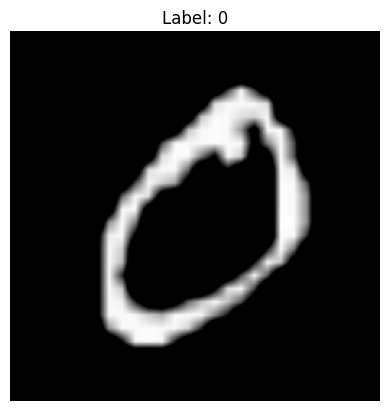

In [5]:
def ShowSmple():
    # img: Tensor [C, H, W] → convert to [H, W, C] for plotting

    img, label = train_data[1]  # first image  ([3, 256, 256])
    print("Image size:", img.shape) 
    img_np = img.permute(1, 2, 0).numpy()
    print("Image size:", img_np.shape) 
    # ----------------
    # Show
    # ----------------
   
    plt.imshow(img_np)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

ShowSmple()

In [6]:

# --------------------
# Dense Block
# --------------------
class DenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate=32, n_layers=4, dropout=False):
        super().__init__()
        self.layers = nn.ModuleList()
        self.dropout = dropout
        self.flag = GlobalFlag   
        for i in range(n_layers):
            self.layers.append(nn.Conv2d(
                in_channels + i * growth_rate, growth_rate, kernel_size=3, padding=1))
            self.layers.append(nn.InstanceNorm2d(growth_rate))
            self.layers.append(nn.LeakyReLU(inplace=True))
            if dropout:
                self.layers.append(nn.Dropout(0.5))

    def forward(self, x):
        features = [x]
        if self.flag:
            logging.info(f"DenseBlock input: {x.shape}")
        for i in range(0, len(self.layers), 4 if self.dropout else 3):
            out = self.layers[i](torch.cat(features, dim=1))
            out = self.layers[i+1](out)
            out = self.layers[i+2](out)
            if self.dropout:
                out = self.layers[i+3](out)
            features.append(out)
        return torch.cat(features, dim=1)


In [7]:
# --------------------
# Encoder Blocks
# --------------------
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, growth_rate=32, dropout=False):
        super().__init__()
        self.flag = GlobalFlag  
        self.dense = DenseBlock(in_channels, growth_rate, n_layers=3, dropout=dropout)
        # Reduce channels to out_channels after dense concatenation
        self.conv1x1 = nn.Conv2d(in_channels + 3*growth_rate, out_channels, kernel_size=1)
        self.downsample = nn.Conv2d(out_channels, out_channels, 4, 2, 1)
        self.relu = nn.LeakyReLU(inplace=True)

    def forward(self, x):
        x = self.dense(x)
        x = self.conv1x1(x)
        x = self.downsample(x)
        if self.flag:
            logging.info(f"EncoderBlock input: {x.shape}")
        return self.relu(x)

In [8]:
# --------------------
# Decoder Blocks
# --------------------
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, growth_rate=32, dropout=False):
        super().__init__()
        self.flag = GlobalFlag  
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1)
        self.dense = DenseBlock(out_channels, growth_rate, n_layers=3, dropout=dropout)
        self.conv1x1 = nn.Conv2d(out_channels + 3*growth_rate, out_channels, kernel_size=1)
        self.relu = nn.LeakyReLU(inplace=True)

    def forward(self, x):
        x = self.up(x)
        x = self.dense(x)
        x = self.conv1x1(x)
        if self.flag:
            logging.info(f"DecoderBlock input: {x.shape}")
        return self.relu(x)


In [9]:
# --------------------
# Dense-UNet Generator (7 encoder blocks)
# --------------------
class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        self.flag = GlobalFlag  
        super().__init__()
        # Encoder
        self.e1 = EncoderBlock(in_channels, 64)
        self.e2 = EncoderBlock(64, 128)
        self.e3 = EncoderBlock(128, 256)
        self.e4 = EncoderBlock(256, 512)
        self.e5 = EncoderBlock(512, 512)
        self.e6 = EncoderBlock(512, 512)
        self.e7 = EncoderBlock(512, 512, dropout=True)

        # Decoder
        self.d1 = DecoderBlock(512, 512, dropout=True)
        self.d2 = DecoderBlock(512+512, 512, dropout=True)  # skip connection
        self.d3 = DecoderBlock(512+512, 512, dropout=True)
        self.d4 = DecoderBlock(512+512, 256)
        self.d5 = DecoderBlock(256+256, 128)
        self.d6 = DecoderBlock(128+128, 64)

        # Final output
        self.final = nn.ConvTranspose2d(64+64, out_channels, 4, 2, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        # Encoder
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        e7 = self.e7(e6)

        # Decoder with skip connections
        d1 = self.d1(e7)
        d2 = self.d2(torch.cat([d1, e6], 1))
        d3 = self.d3(torch.cat([d2, e5], 1))
        d4 = self.d4(torch.cat([d3, e4], 1))
        d5 = self.d5(torch.cat([d4, e3], 1))
        d6 = self.d6(torch.cat([d5, e2], 1))
        out = self.final(torch.cat([d6, e1], 1))
        if self.flag:
            logging.info(f"Generator input: {x.shape}")
        return self.tanh(out)

In [10]:
# --------------------
# Discriminator
# --------------------
class Discriminator(nn.Module):
    def __init__(self, in_channels=3, global_flag=False):
        super().__init__()
        self.flag = global_flag  # 👈 استفاده از flag برای لاگ‌گیری

        # Patch-based discriminator with progressively increasing filters
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 512, kernel_size=4, stride=1, padding=1), 
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        if self.flag:
            logging.info(f"Discriminator input: {x.shape}")
        return self.model(x)

In [11]:
# --------------------
# Init Loss & Optimizers
# --------------------
G = Generator().to(device)
D = Discriminator().to(device)

adversarial_loss = nn.BCELoss()
mse_loss = nn.MSELoss()
l1_loss = nn.L1Loss()

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [12]:
def plot_ssim_changes(ssim_values, title="SSIM changes"):
    """
    ssim_values: list or numpy array of SSIM values
    """
    ssim_values = np.array(ssim_values)

    plt.figure(figsize=(8,4))
    plt.plot(ssim_values, marker='o')
    plt.xlabel("Image index")
    plt.ylabel("SSIM")
    plt.ylim(0, 1)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [ ]:
# --------------------
# TRAINING LOOP ✅
# --------------------
ssim_values = []

for epoch in range(epochs):
    G.train()
    D.train()

    for imgs, _ in train_loader:
        imgs = imgs.to(device)

        # ======================
        #  Train Generator
        # ======================
        gen_imgs = G(imgs)                  #Give imgs to the generator G and output is generated image gen_imgs

        pred_fake = D(gen_imgs)           #prediction gen_imgs is fake or real
        valid = torch.ones_like(pred_fake)

        g_adv_loss = adversarial_loss(pred_fake, valid)
        #g_l2_loss  = mse_loss(gen_imgs, imgs)
        g_l1_loss = l1_loss(gen_imgs, imgs)

        loss_G = lambda_G * g_adv_loss + lambda_L2 * g_l1_loss

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        # ======================
        #  Train Discriminator
        # ======================
        pred_real = D(imgs)
        real_loss = adversarial_loss(pred_real, torch.ones_like(pred_real))

        pred_fake = D(gen_imgs.detach())
        fake_loss = adversarial_loss(pred_fake, torch.zeros_like(pred_fake))

        d_loss = 0.5 * (real_loss + fake_loss)

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    # ======================
    #  Validation
    # ======================
    G.eval()
    mse_val, ssim_epoch, n = 0.0, 0.0, 0

    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            gen = G(imgs)

            mse_val += mse_loss(gen, imgs).item()

            # [-1,1] → [0,1]
            gen_np  = (gen.cpu().numpy()  + 1) / 2
            real_np = (imgs.cpu().numpy() + 1) / 2

            for i in range(gen_np.shape[0]):
                ssim_epoch += ssim(
                    np.transpose(real_np[i], (1, 2, 0)),
                    np.transpose(gen_np[i], (1, 2, 0)),
                    channel_axis=2,
                    data_range=1.0
                )
                n += 1

    ssim_epoch /= n
    mse_epoch = mse_val / len(val_loader)

    ssim_values.append(ssim_epoch)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"G: {loss_G.item():.4f} | "
        f"D: {d_loss.item():.4f} | "
        f"MSE: {mse_epoch:.4f} | "
        f"SSIM: {ssim_epoch:.4f}"
    )


plot_ssim_changes(ssim_values, title="SSIM changes")

Epoch [1/100] | G: 75.6648 | D: 0.5964 | MSE: 0.4984 | SSIM: 0.0290
Epoch [2/100] | G: 56.8829 | D: 0.8103 | MSE: 0.3028 | SSIM: 0.0535
Epoch [3/100] | G: 42.8204 | D: 0.3931 | MSE: 0.1758 | SSIM: 0.0809
Epoch [4/100] | G: 32.6380 | D: 0.2680 | MSE: 0.1015 | SSIM: 0.1077
Epoch [5/100] | G: 23.9503 | D: 0.1813 | MSE: 0.0599 | SSIM: 0.1319
Epoch [6/100] | G: 17.2783 | D: 0.1427 | MSE: 0.0292 | SSIM: 0.1727
Epoch [7/100] | G: 12.4311 | D: 1.3032 | MSE: 0.0169 | SSIM: 0.2451
Epoch [8/100] | G: 9.2154 | D: 1.0369 | MSE: 0.0118 | SSIM: 0.3671
Epoch [9/100] | G: 6.8810 | D: 0.7061 | MSE: 0.0093 | SSIM: 0.5219
Epoch [10/100] | G: 5.4279 | D: 0.5969 | MSE: 0.0078 | SSIM: 0.6618
Epoch [11/100] | G: 4.8602 | D: 0.5349 | MSE: 0.0080 | SSIM: 0.7489
Epoch [12/100] | G: 4.5402 | D: 0.6674 | MSE: 0.0097 | SSIM: 0.7935
Epoch [13/100] | G: 5.4079 | D: 0.6838 | MSE: 0.0104 | SSIM: 0.8321
Epoch [14/100] | G: 5.1207 | D: 0.6775 | MSE: 0.0078 | SSIM: 0.8699
Epoch [15/100] | G: 3.4990 | D: 0.6450 | MSE: 0.00

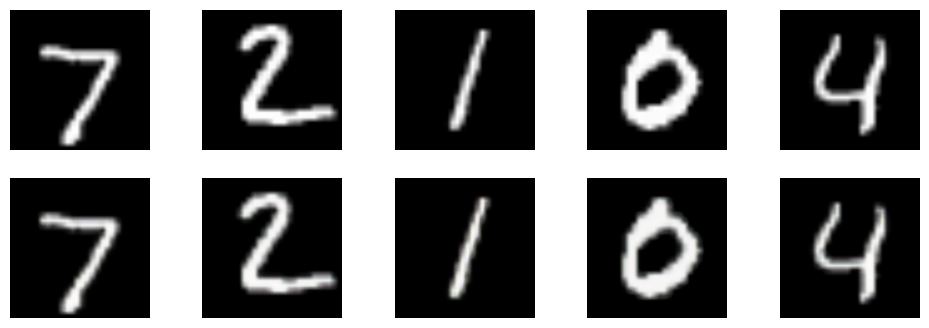

In [ ]:
# --------------------
# Generate & Show Images
# --------------------
def show_results(model, loader):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:5].to(device)

    with torch.no_grad():
        gen = model(imgs)

    imgs = (imgs.cpu() + 1) / 2
    gen = (gen.cpu() + 1) / 2

    plt.figure(figsize=(12,4))
    for i in range(5):
        plt.subplot(2,5,i+1)
        plt.imshow(imgs[i].permute(1,2,0))
        plt.axis("off")
        plt.subplot(2,5,i+6)
        plt.imshow(gen[i].permute(1,2,0))
        plt.axis("off")
    plt.show()

show_results(G, val_loader)


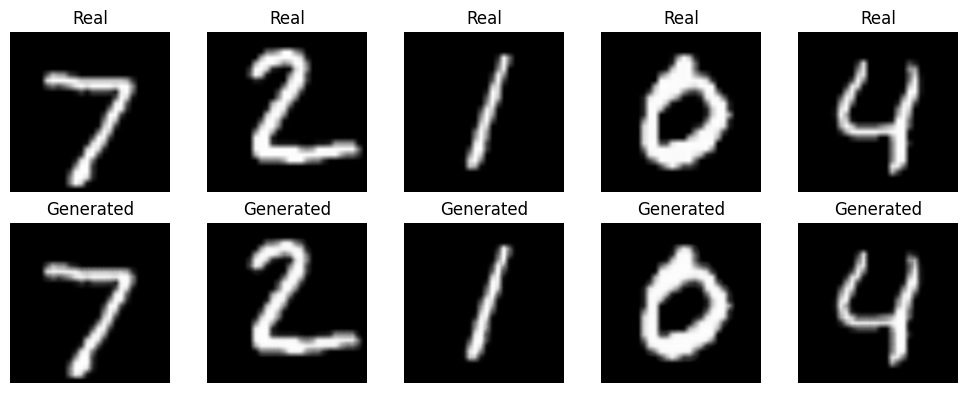

In [ ]:
def generate_and_evaluate_ssim(generator, dataloader, device, num_images=5):
    """
    Generate images from a UNet-like generator and evaluate SSIM.
    No latent noise vector is used, input is real images.
    """
    generator.eval()

    # Get a batch of real images
    real_imgs, _ = next(iter(dataloader))
    real_imgs = real_imgs[:num_images].to(device)

    # Generate images using the generator (image-to-image)
    with torch.no_grad():
        gen_imgs = generator(real_imgs)

    # Convert tensors to numpy
    real_imgs = real_imgs.cpu().numpy()
    gen_imgs  = gen_imgs.cpu().numpy()

    # UNet images are [C,H,W]; convert to [H,W] grayscale if C=1 or pick one channel if C>1
    if real_imgs.shape[1] > 1:
        real_imgs = real_imgs[:,0,:,:]  # take first channel
        gen_imgs  = gen_imgs[:,0,:,:]

    # Denormalize from [-1,1] to [0,1]
    real_imgs = (real_imgs + 1) / 2
    gen_imgs  = (gen_imgs + 1) / 2

    ssim_scores = []

    # Plot real vs generated
    plt.figure(figsize=(10,4))
    for i in range(num_images):
        plt.subplot(2, num_images, i+1)
        plt.imshow(real_imgs[i], cmap="gray")
        plt.title("Real")
        plt.axis("off")

        plt.subplot(2, num_images, i+1+num_images)
        plt.imshow(gen_imgs[i], cmap="gray")
        plt.title("Generated")
        plt.axis("off")

    plt.tight_layout()
    plt.show()



# Example usage
generate_and_evaluate_ssim(G, val_loader, device, num_images=5)


In [ ]:
real_imgs, _ = next(iter(train_loader))
real_imgs = real_imgs[:1].to(device)
gen_imgs = G(real_imgs)

real_imgs = (real_imgs + 1) / 2    #[-1,+1]->[0,1]
gen_imgs = (gen_imgs + 1) / 2

In [ ]:
# --------------------
# NMSE: Normalized MSE ↓
# --------------------
def NMSE(x, y):        # x, y: [B, C, H, W], values [0,1]
    mse = F.mse_loss(x, y, reduction='none')
    nmse = mse.view(mse.size(0), -1).sum(dim=1) / (y.view(y.size(0), -1)**2).sum(dim=1)
    return nmse.mean().item()

In [ ]:
# --------------------
# NMAE: Normalized MAE ↓
# --------------------
def NMAE(x, y, eps=1e-8):
    num = torch.abs(x - y).view(x.size(0), -1).sum(dim=1)
    den = torch.abs(y).view(y.size(0), -1).sum(dim=1) + eps
    return (num / den).mean().item()

In [ ]:
# --------------------
# PSNR ↑
# --------------------
def PSNR(x, y, max_val=1.0):
    x_np = x.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy()
    psnr_vals = [psnr(y_np[i], x_np[i], data_range=max_val) for i in range(x_np.shape[0])]
    return np.mean(psnr_vals)

In [ ]:
# --------------------
# SSIM ↑
# --------------------
def SSIM(x, y):
    x_np = x.detach().cpu().numpy().astype(np.float32)
    y_np = y.detach().cpu().numpy().astype(np.float32)
    
    ssim_vals = []
    for i in range(x_np.shape[0]):
        # از [C,H,W] به [H,W,C]
        ssim_val = ssim(
            y_np[i].transpose(1,2,0),
            x_np[i].transpose(1,2,0),
            multichannel=True,
            data_range=1.0
        )
        ssim_vals.append(ssim_val)
    
    return np.mean(ssim_vals)

In [ ]:
# --------------------
# MS-SSIM ↓ (1 - ms-ssim)
# --------------------
def MS_SSIM(x, y):
    return 1 - ms_ssim(x, y, data_range=1.0, size_average=True).item()

In [ ]:
# --------------------
# LPIPS ↓
# --------------------

lpips_alex = lpips.LPIPS(net='alex').to(device)
def LPIPS(x, y):
    return lpips_alex(x*2-1, y*2-1).mean().item()  # scale to [-1,1]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\fhabi\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\fhabi\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\fhabi\AppData\Local\Programs\Python\Python310\lib\site-packages\lpips\weights\v0.1\alex.pth


In [ ]:
# --------------------
# FID ↓
# --------------------
# Matrix square root using SVD
def sqrtm_torch(A):
    U, S, Vh = torch.linalg.svd(A)
    sqrt_S = torch.sqrt(S)
    return (U * sqrt_S) @ Vh

# FID function
def FID(x, y, device='cpu'):
    x_rgb = x.repeat(1, 3, 1, 1)
    y_rgb = y.repeat(1, 3, 1, 1)

    # Load InceptionV3
    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.eval()
    inception.fc = nn.Identity()
    pool = AdaptiveAvgPool2d((1, 1))

    def get_features(imgs):
        imgs = F.interpolate(imgs, size=(299, 299), mode='bilinear', align_corners=False)
        with torch.no_grad():
            feats = inception(imgs)
            feats = pool(feats).view(feats.size(0), -1)  # [B, 2048]
        return feats

    feats_x = get_features(x.to(device))
    feats_y = get_features(y.to(device))

    mu_x, sigma_x = feats_x.mean(0), torch.cov(feats_x.T)
    mu_y, sigma_y = feats_y.mean(0), torch.cov(feats_y.T)

    diff = mu_x - mu_y
    covmean = sqrtm_torch(sigma_x @ sigma_y + 1e-6 * torch.eye(sigma_x.shape[0], device=device))

    fid_score = (diff @ diff + torch.trace(sigma_x + sigma_y - 2 * covmean)).item()
    return fid_score

In [ ]:
print('NMSE(↓):',NMSE(gen_imgs,real_imgs))
print('NMAE(↓):',NMAE(gen_imgs,real_imgs))
print('PSNR(↑):',PSNR(gen_imgs,real_imgs))
#print('SSIM(↑):',SSIM(gen_imgs,real_imgs))
print('MS_SSIM(↑):',MS_SSIM(gen_imgs,real_imgs))
#print('FID(↓):',FID(gen_imgs,real_imgs))
print('LPIPS(↓):',LPIPS(gen_imgs,real_imgs))


NMSE(↓): 0.002207751153036952
NMAE(↓): 0.04506124556064606
PSNR(↑): 36.37574258237424
MS_SSIM(↑): 0.002141237258911133
LPIPS(↓): 0.025634173303842545
